# W02 Preprocessing Pipeline

**Platform:** Aido Rover 
**Seed:** 42  
**Sampling rate:** 10 Hz

Pipeline overview:
1. Synthetic dataset generation (synthetic_rover_data.csv)
2. Cleaning & data-quality report
3. FFT (torque × 4 + LiDAR × 1, 5 spectral features each)
4. PCA — 95% variance retention
5. RF feature selection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Synthetic Aido Rover Dataset Generation
### Data pattern:
**Anomaly structure:**
85% normal / 15% anomalous, anomalies clustered in time;  
correlated with SoC drops and torque spikes
| Channel | Type | Anomaly effect |
|---|---|---|
| gps_lat, gps_lon | random-walk patrol path | none  |
| lidar_distance | obstacle proximity (m) | none  |
| battery_soc | monotone discharge (%) | faster drain |
| torque_0 – torque_3 | wheel drive torques (Nm) | 3–5× spike |
| ambient_temp | slow sinusoidal drift (°C) | none  |
| anomaly_label | 0 = normal, 1 = anomalous | — |


In [3]:
# ── Parameters ──────────────────────────────────────────────────────────────
N_SAMPLES   = 15000
FS          = 10.0 # hz
DT          = 1.0 / FS

# bursts(30) * mean length(75) / N_SAMPLES(15000) = 15%
N_BURSTS      = 30
MIN_BURST_LEN = 20    # 2 s
MAX_BURST_LEN = 130   # 13 s

# ── Build anomaly mask ───────────────────────────────────────────────────────
_rng_mask = np.random.default_rng(SEED)

anomaly_mask = np.zeros(N_SAMPLES, dtype=bool)
burst_starts  = sorted(_rng_mask.choice(N_SAMPLES - MAX_BURST_LEN, N_BURSTS, replace=False))
burst_lengths = _rng_mask.integers(MIN_BURST_LEN, MAX_BURST_LEN + 1, N_BURSTS)

for start, length in zip(burst_starts, burst_lengths):
    end = min(start + length, N_SAMPLES)
    anomaly_mask[start:end] = True

actual_pct = anomaly_mask.mean() * 100
print(f'Anomaly coverage: {actual_pct:.1f}%')
print(f'Normal samples  : {(~anomaly_mask).sum()}')
print(f'Anomaly samples : {anomaly_mask.sum()}')

Anomaly coverage: 14.9%
Normal samples  : 12772
Anomaly samples : 2228


In [4]:
# ── Timestamp index ──────────────────────────────────────────────────────────
timestamps = pd.date_range(
    start='2026-06-24 08:00:00',
    periods=N_SAMPLES,
    freq=f'{int(DT * 1000)}ms'
)

_rng_data = np.random.default_rng(SEED)

# ── GPS ─────────────────────────────────────────────
lat_steps = _rng_data.normal(0, 0.00001, N_SAMPLES) # 1 m per step
lon_steps = _rng_data.normal(0, 0.00001, N_SAMPLES)

gps_lat = np.cumsum(lat_steps)
gps_lon = np.cumsum(lon_steps)

# ── LiDAR ──────────────────────────────────────────────────────────
lidar_distance = _rng_data.uniform(2000.0, 8000.0, N_SAMPLES) # mm
lidar_distance += _rng_data.normal(0, 50.0, N_SAMPLES)  # sensor noise
lidar_distance = np.clip(lidar_distance, 1000.0, 15000.0)

# ── Battery SoC ─────────────────────────────────────────────────────────────
# Normal: −0.002 %/step; anomaly: −0.005 %/step 
discharge = np.where(anomaly_mask, 0.005, 0.002)
discharge += _rng_data.normal(0, 0.0005, N_SAMPLES)    # measurement noise
battery_soc = 100.0 - np.cumsum(discharge)
battery_soc = np.clip(battery_soc, 0.0, 100.0)

# ── Wheel torques (4 channels) ───────────────────────────────────────────────
# Normal: correlated Gaussian around 5 Nm with slight cross-wheel correlation
base_torque = 5.0
cov = np.array([[1.0, 0.6, 0.3, 0.1],
                [0.6, 1.0, 0.6, 0.3],
                [0.3, 0.6, 1.0, 0.6],
                [0.1, 0.3, 0.6, 1.0]])  # correlated wheel torques
torques_normal = _rng_data.multivariate_normal(np.zeros(4), cov, N_SAMPLES) + base_torque

# Anomaly: multiply by a random spike factor
spike_factor = _rng_data.uniform(3.0, 5.0, (N_SAMPLES, 4))
torques = np.where(anomaly_mask[:, None], torques_normal * spike_factor, torques_normal)
torques = np.clip(torques, 0.0, 50.0)  # 50 as physical upper bound

torque_0, torque_1, torque_2, torque_3 = torques.T

# ── Ambient temperature ──────────────────────────────────────────────────────
t = np.arange(N_SAMPLES) * DT
ambient_temp = 28.0 + 3.0 * np.sin(2 * np.pi * t / 600) + _rng_data.normal(0, 0.2, N_SAMPLES)

print('Channels generated')

Channels generated


In [5]:
# Assemble DataFrame
df = pd.DataFrame({
    'timestamp'     : timestamps,
    'gps_lat'       : gps_lat,
    'gps_lon'       : gps_lon,
    'lidar_distance': lidar_distance,
    'battery_soc'   : battery_soc,
    'torque_0'      : torque_0,
    'torque_1'      : torque_1,
    'torque_2'      : torque_2,
    'torque_3'      : torque_3,
    'ambient_temp'  : ambient_temp,
    'anomaly_label' : anomaly_mask.astype(int),
})
df = df.set_index('timestamp')

# Simulate sensor data missing: randomly drop 0.5%
_rng_missing = np.random.default_rng(SEED)
sensor_cols = [c for c in df.columns if c != 'anomaly_label']
mask = _rng_missing.random((len(df), len(sensor_cols))) < 0.005
df[sensor_cols] = df[sensor_cols].where(~mask)

out_path = DATA_DIR / 'synthetic_rover_data.csv'
df.to_csv(out_path)

print(f'Data saved to {out_path.resolve()}')

Data saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/synthetic_rover_data.csv


## Cleaning & Quality report



### Dataset Validation

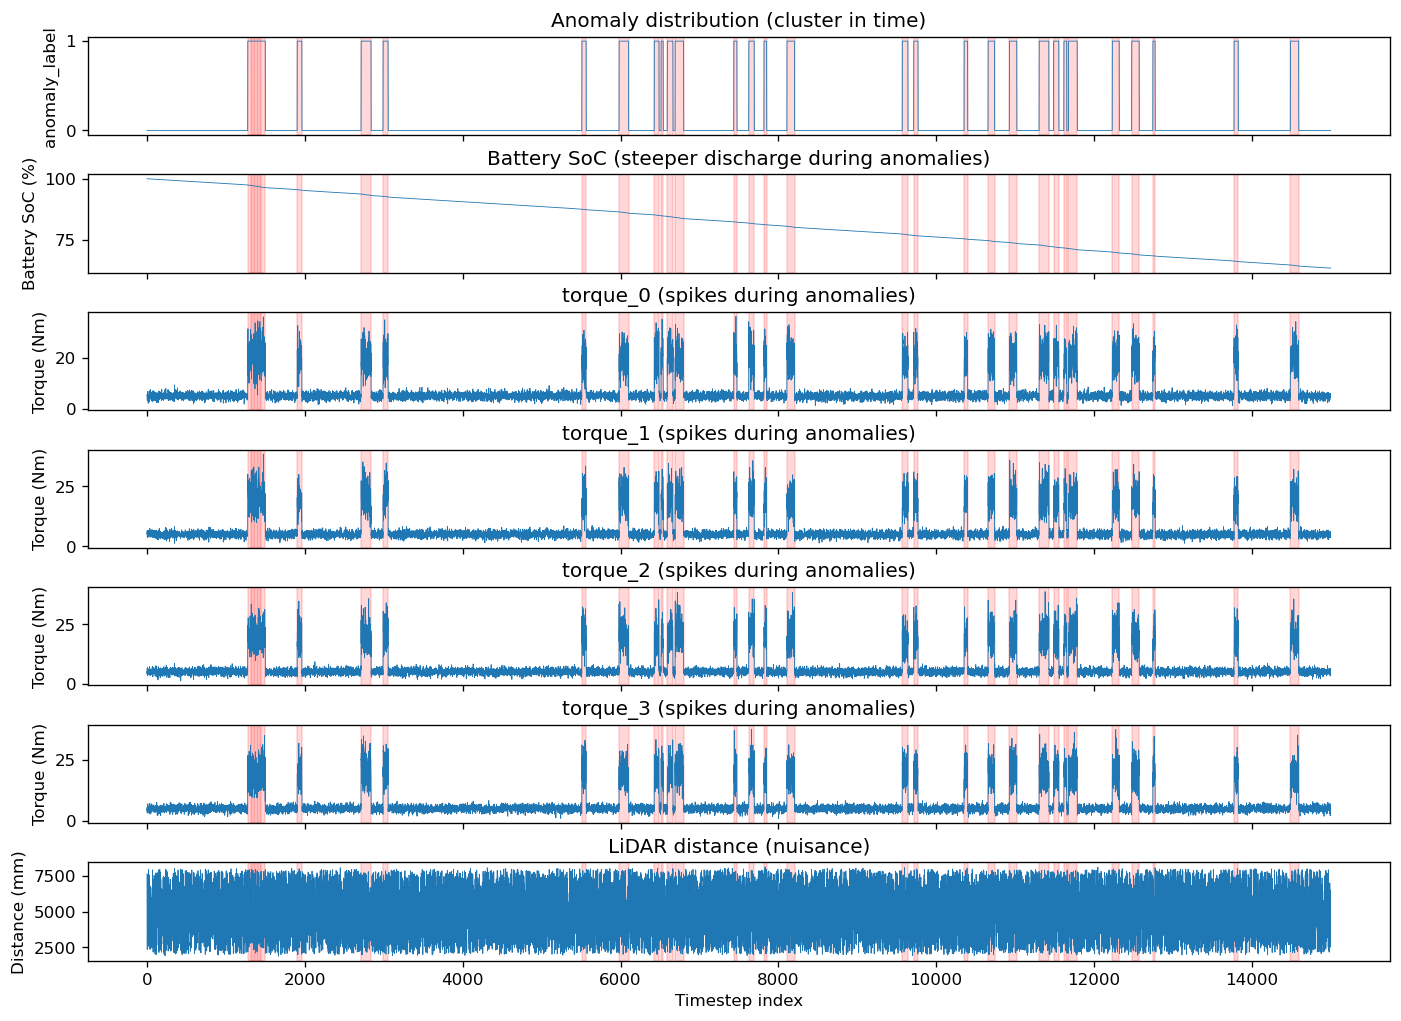

In [6]:
# ── Anomaly Distribution Plot───────────────────────────────────────────────────────

fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.4)

panels = [
    (anomaly_mask.astype(int), 'anomaly_label',  'Anomaly distribution (cluster in time)'),
    (battery_soc,              'Battery SoC (%)','Battery SoC (steeper discharge during anomalies)'),
    (torque_0,                 'Torque (Nm)',    'torque_0 (spikes during anomalies)'),
    (torque_1,                 'Torque (Nm)',    'torque_1 (spikes during anomalies)'),
    (torque_2,                 'Torque (Nm)',    'torque_2 (spikes during anomalies)'),
    (torque_3,                 'Torque (Nm)',    'torque_3 (spikes during anomalies)'),
    (lidar_distance,           'Distance (mm)',  'LiDAR distance (nuisance)'),
]

for ax, (data, ylabel, title) in zip(axes, panels):
    ax.plot(data, lw=0.5)
    for start, length in zip(burst_starts, burst_lengths):
        ax.axvspan(start, min(start + length, N_SAMPLES), color='red', alpha=0.15)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[-1].set_xlabel('Timestep index')
plt.show()


In [7]:
# ── Dataset summary ──────────────────────────────────────────────────────────
print('Dataset Summary')
print(f'Total rows     : {len(df):,}')
print(f'Sampling rate  : {FS} Hz')
print(f'Duration       : {len(df) * DT / 60:.1f} min')
print(f'Anomaly bursts : {N_BURSTS} bursts, length {MIN_BURST_LEN}-{MAX_BURST_LEN} steps')
print(f'Anomaly %      : {anomaly_mask.mean()*100:.1f}%')
print(f'Features       : {df.shape[1] - 1} sensor channels + 1 label')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Timestamp gaps : {(df.index.to_series().diff().dropna() != pd.Timedelta("100ms")).sum()}')
df.describe().round(3)

Dataset Summary
Total rows     : 15,000
Sampling rate  : 10.0 Hz
Duration       : 25.0 min
Anomaly bursts : 30 bursts, length 20-130 steps
Anomaly %      : 14.9%
Features       : 9 sensor channels + 1 label
Missing values : 718
Duplicate rows : 0
Timestamp gaps : 0


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,anomaly_label
count,14932.000,14920.000,14919.000,14916.000,14923.000,14922.000,14925.000,14913.000,14912.000,15000.000
mean,-0.001,0.003,5001.722,81.963,7.194,7.227,7.259,7.236,28.381,0.149
std,0.000,0.001,1735.851,10.724,5.702,5.727,5.794,5.723,2.095,0.356
min,-0.002,-0.000,1878.121,63.345,1.163,1.256,1.137,0.947,24.490,0.000
25%,-0.001,0.001,3487.460,72.955,4.442,4.463,4.477,4.464,26.346,0.000
50%,-0.001,0.003,5024.170,82.116,5.216,5.231,5.241,5.232,28.779,0.000
75%,-0.001,0.004,6505.022,91.075,6.159,6.177,6.212,6.203,30.362,0.000
max,0.000,0.005,8145.010,99.997,36.307,38.384,38.715,37.683,31.582,1.000


### Cleaning

In [8]:
df_raw = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
sensor_cols = [c for c in df_raw.columns if c != 'anomaly_label']

null_before = df_raw[sensor_cols].isnull().sum()
print(f'Missing values before cleaning: {null_before.sum()}')

df_clean = df_raw.ffill().bfill()

quality_report = df_clean[sensor_cols].agg(['mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T
quality_report['null_before'] = null_before
quality_report['null_after']  = df_clean[sensor_cols].isnull().sum()
quality_report['outliers_3std'] = (
    (df_clean[sensor_cols] - df_clean[sensor_cols].mean()).abs()
    > 3 * df_clean[sensor_cols].std()
).sum()
print('Data quality report (after cleaning):')
quality_report.round(3)

Missing values before cleaning: 718
Data quality report (after cleaning):


,mean,std,min,max,skew,kurtosis,null_before,null_after,outliers_3std
gps_lat,-0.001,0.000,-0.002,0.000,-0.249,-0.899,68,0,0
gps_lon,0.003,0.001,-0.000,0.005,-0.365,-1.025,80,0,0
lidar_distance,5002.459,1736.250,1878.121,8145.010,-0.010,-1.206,81,0,0
battery_soc,81.957,10.724,63.345,99.997,-0.054,-1.205,84,0,0
torque_0,7.197,5.704,1.163,36.307,2.334,4.541,77,0,417
torque_1,7.226,5.726,1.256,38.384,2.320,4.458,78,0,415
torque_2,7.264,5.799,1.137,38.715,2.354,4.691,75,0,407
torque_3,7.231,5.715,0.947,37.683,2.327,4.493,87,0,423
ambient_temp,28.382,2.095,24.490,31.582,-0.301,-1.353,88,0,0


### FFT

In [ ]:
from scipy.fft import rfft, rfftfreq


WINDOW = 50  # 5s at 10Hz
FFT_CHANNELS = ['torque_0', 'torque_1', 'torque_2', 'torque_3', 'lidar_distance']

def fft_features(seg, fs = FS):
    
    freqs = rfftfreq(len(seg), d=1/fs)
    mag = np.abs(rfft(seg))
    mag[0] = 0

    dom_freq    = freqs[np.argmax(mag)]
    centroid    = np.dot(freqs, mag) / (np.sum(mag) )
    bandwidth   = np.sqrt(np.dot((freqs - centroid)**2, mag) / (np.sum(mag) ))
    total_power = np.dot(mag, mag)
    peak_to_mean = np.max(mag) / (np.mean(mag))

    return [dom_freq, centroid, bandwidth, total_power, peak_to_mean]


fft_names = [f'{channel}_{feature}' 
             for channel in FFT_CHANNELS
             for feature in ['dom_freq', 'centroid', 'bandwidth', 'total_power', 'peak_to_mean']]
feature_names = sensor_cols + fft_names

rows,label = [],[]
for i in range(WINDOW, len(df_clean)):

    raw = df_clean[sensor_cols].iloc[i].values.tolist()
    fft = [v for channel in FFT_CHANNELS 
            for v in fft_features(df_clean[channel].iloc[i-WINDOW:i].values)]
    rows.append(raw + fft)
    label.append(df_clean['anomaly_label'].iloc[i])

feature_matrix= np.array(rows)
label_array = np.array(label)

print('Feature matrix preview:')
pd.DataFrame(feature_matrix[:10], columns=feature_names).round(3)

Feature matrix preview:


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,torque_0_dom_freq,...,torque_3_dom_freq,torque_3_centroid,torque_3_bandwidth,torque_3_total_power,torque_3_peak_to_mean,lidar_distance_dom_freq,lidar_distance_centroid,lidar_distance_bandwidth,lidar_distance_total_power,lidar_distance_peak_to_mean
0,0.0,0.0,4482.713,99.901,3.795,4.743,4.711,3.116,28.228,1.6,...,1.4,2.653,1.420,1123.556,2.487,2.6,2.641,1.325,3.895330e+09,2.089
1,0.0,0.0,4262.978,99.900,5.732,6.826,5.385,4.521,28.047,1.2,...,1.4,2.584,1.436,1200.267,2.009,2.6,2.649,1.312,3.630474e+09,1.970
2,0.0,0.0,4337.058,99.898,5.537,5.896,5.036,7.053,28.183,1.2,...,1.4,2.599,1.432,1187.578,2.037,1.2,2.647,1.320,3.633370e+09,2.008
3,0.0,0.0,4968.865,99.897,4.827,5.423,6.085,6.439,28.166,1.2,...,3.6,2.720,1.366,1294.713,2.078,1.2,2.635,1.324,3.629133e+09,2.024
4,0.0,0.0,4817.308,99.895,4.791,4.077,4.415,4.840,28.187,1.2,...,0.4,2.639,1.361,1230.384,1.725,1.2,2.672,1.336,3.447776e+09,2.177
5,0.0,0.0,2636.226,99.893,6.206,6.145,4.878,4.579,28.386,1.2,...,0.4,2.634,1.366,1226.259,1.759,1.2,2.644,1.343,3.438781e+09,2.306
6,0.0,0.0,3691.812,99.891,3.257,5.262,6.001,5.821,28.169,1.2,...,2.0,2.617,1.348,1228.385,1.812,5.0,2.706,1.390,3.434104e+09,2.268
7,0.0,0.0,2807.980,99.888,3.179,4.486,4.777,6.420,28.162,1.2,...,2.0,2.593,1.379,1236.843,1.818,1.8,2.638,1.403,3.398977e+09,2.226
8,0.0,0.0,5682.608,99.886,3.337,4.680,3.789,4.102,27.950,1.2,...,2.0,2.620,1.379,1210.637,1.772,5.0,2.604,1.434,3.500082e+09,2.182
9,0.0,0.0,4480.877,99.884,5.370,6.160,4.806,3.905,28.410,1.2,...,1.2,2.620,1.324,1143.493,2.063,5.0,2.709,1.451,3.544803e+09,2.452


### PCA

Components retained: 19 (from 34)
Variance explained : 0.9512


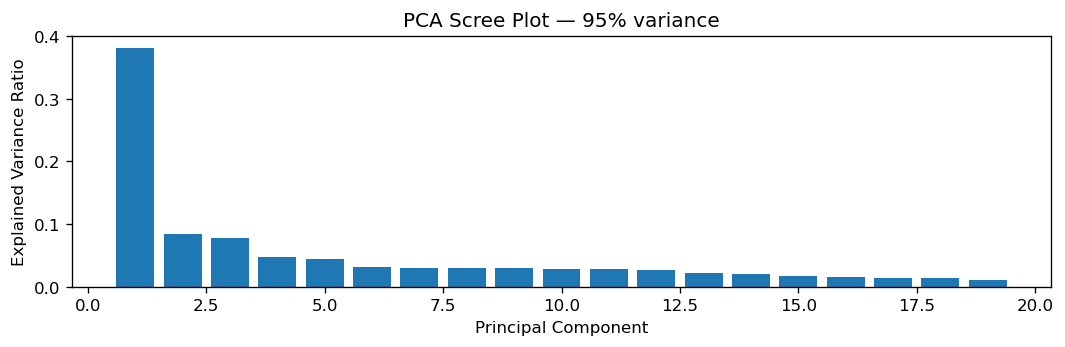

Top-5 loading features per PC:
PC1: ['torque_1_total_power', 'torque_3_total_power', 'torque_0_total_power', 'torque_2_total_power', 'torque_3_peak_to_mean']
PC2: ['torque_1', 'torque_2', 'torque_3', 'torque_0', 'battery_soc']
PC3: ['battery_soc', 'gps_lon', 'gps_lat', 'torque_2', 'torque_1']
PC4: ['lidar_distance_dom_freq', 'lidar_distance_centroid', 'torque_1_bandwidth', 'torque_0_bandwidth', 'torque_2_bandwidth']
PC5: ['lidar_distance_centroid', 'lidar_distance_dom_freq', 'torque_1_bandwidth', 'torque_2_bandwidth', 'torque_0_bandwidth']


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ── Stratified 70 / 15 / 15 split ─────────────────────
X_tr_raw, X_tmp, y_tr_s, y_tmp = train_test_split(
    feature_matrix, label_array, test_size=0.30, stratify=label_array, random_state=SEED)
X_va_raw, X_te_raw, y_va_s, y_te_s = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# Fit scaler and PCA on train set
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_raw)
X_va_sc = scaler.transform(X_va_raw)
X_te_sc = scaler.transform(X_te_raw)

pca = PCA(n_components=0.95, random_state=SEED)
X_tr_s = pca.fit_transform(X_tr_sc)
X_va_s = pca.transform(X_va_sc)
X_te_s = pca.transform(X_te_sc)

print(f'Components retained: {pca.n_components_} (from {X_tr_raw.shape[1]})')
print(f'Variance explained : {pca.explained_variance_ratio_.sum():.4f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot — 95% variance')
plt.tight_layout()
plt.show()

print('Top-5 loading features per PC:')
for i in range(min(5, pca.n_components_)):
    top5 = pd.Series(np.abs(pca.components_[i]), index=feature_names).nlargest(5)
    print(f'PC{i+1}: {top5.index.tolist()}')

### RF


Stratified 70/15/15 split (PCA feature space)
  train: 10,465  |  normal=8,905  anomaly=1,560  (14.9%)
  val  :  2,242  |  normal=1,908  anomaly=334  (14.9%)
  test :  2,243  |  normal=1,909  anomaly=334  (14.9%)

Baseline RF — all 19 PCA components — val acc: 99.91%
 done.

Full-set val accuracy : 99.91%  (19 components)
2 pp threshold        : 97.91%
Minimal top-K         : 2 component(s)
Top-K val accuracy    : 99.96%  (delta = -0.04 pp)


,Component,Importance
Rank,,
1,PC2,0.4718
2,PC1,0.3418


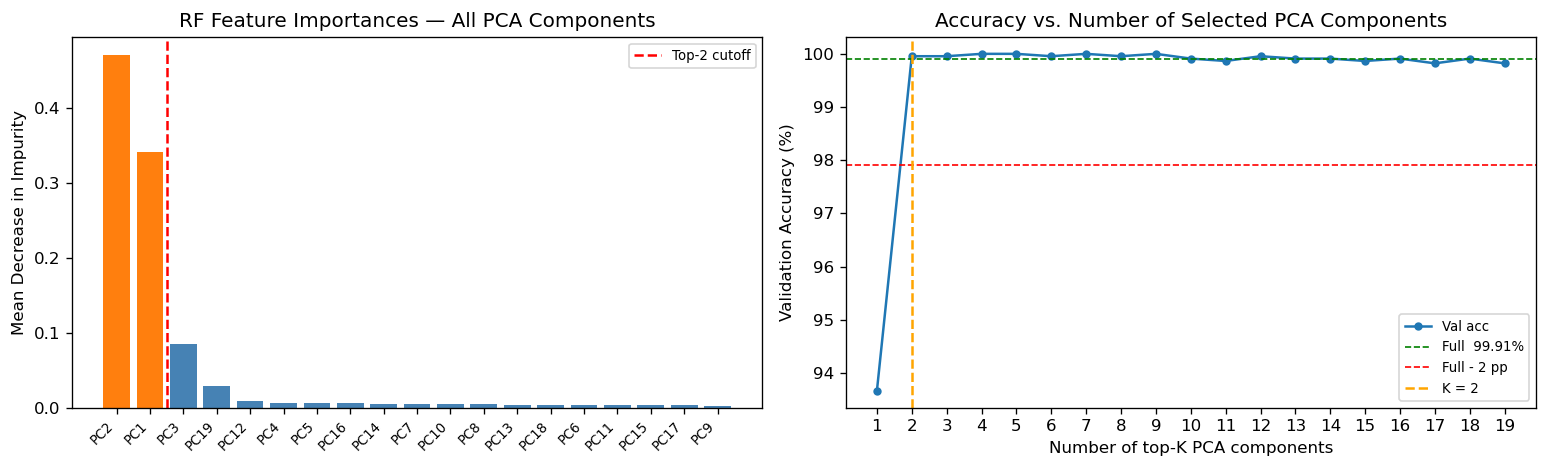


── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────
  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space
  Rover result : 99.96% val acc  |  2 PCA component(s)
  delta from full-feature set : -0.04 pp
  Both tasks achieve near-optimal performance with very few features;
  CNC relies on raw positional features, Rover relies on a compact spectral + time-domain PCA representation.


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Split done in PCA cell; X_tr_s / X_va_s / X_te_s are PCA-transformed features
print('Stratified 70/15/15 split (PCA feature space)')
for name, y_split in [('train', y_tr_s), ('val', y_va_s), ('test', y_te_s)]:
    print(f'  {name:5s}: {len(y_split):>6,}  |  normal={(y_split==0).sum():,}  '
          f'anomaly={(y_split==1).sum():,}  ({(y_split==1).mean()*100:.1f}%)')

# ── Baseline RF on all PCA components ─────────────────────────────────────
n_pca_comps = X_tr_s.shape[1]
pca_names   = [f'PC{i+1}' for i in range(n_pca_comps)]

rf_full      = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_full.fit(X_tr_s, y_tr_s)
full_val_acc = rf_full.score(X_va_s, y_va_s)
importances  = rf_full.feature_importances_
order        = np.argsort(importances)[::-1]

print(f'\nBaseline RF — all {n_pca_comps} PCA components — val acc: {full_val_acc*100:.2f}%')

# ── Accuracy for each top-K ────────
all_k_accs = []
for k in range(1, n_pca_comps + 1):
    idx_k = order[:k]
    rf_k  = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf_k.fit(X_tr_s[:, idx_k], y_tr_s)
    all_k_accs.append(rf_k.score(X_va_s[:, idx_k], y_va_s))
print(' done.')

# ── Minimal top-K within 2 pp of full-feature accuracy ────────────────────
threshold  = full_val_acc - 0.02
best_k     = next(k + 1 for k, acc in enumerate(all_k_accs) if acc >= threshold)
best_acc_k = all_k_accs[best_k - 1]
best_idx   = order[:best_k].copy()
delta_pp   = (full_val_acc - best_acc_k) * 100

selected_names       = [pca_names[i] for i in best_idx]
selected_importances = importances[best_idx]

# ── Tabular report ─────────────────────────────────────────────────────────
print(f'\nFull-set val accuracy : {full_val_acc*100:.2f}%  ({n_pca_comps} components)')
print(f'2 pp threshold        : {threshold*100:.2f}%')
print(f'Minimal top-K         : {best_k} component(s)')
print(f'Top-K val accuracy    : {best_acc_k*100:.2f}%  (delta = {delta_pp:.2f} pp)')

feat_df = (pd.DataFrame({'Component': selected_names, 'Importance': selected_importances})
             .sort_values('Importance', ascending=False)
             .reset_index(drop=True))
feat_df.index = feat_df.index + 1
feat_df.index.name = 'Rank'
display(feat_df.round(4))

# ── Importance bar chart + accuracy-vs-K curve ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tab:orange' if i < best_k else 'steelblue' for i in range(n_pca_comps)]
axes[0].bar(range(n_pca_comps), importances[order], color=colors)
axes[0].set_xticks(range(n_pca_comps))
axes[0].set_xticklabels([pca_names[i] for i in order], rotation=45, ha='right', fontsize=8)
axes[0].axvline(best_k - 0.5, color='red', ls='--', lw=1.5, label=f'Top-{best_k} cutoff')
axes[0].set_ylabel('Mean Decrease in Impurity')
axes[0].set_title('RF Feature Importances — All PCA Components')
axes[0].legend(fontsize=8)

axes[1].plot(range(1, n_pca_comps + 1), [a * 100 for a in all_k_accs], 'o-', ms=4, label='Val acc')
axes[1].axhline(full_val_acc * 100, color='green', ls='--', lw=1, label=f'Full  {full_val_acc*100:.2f}%')
axes[1].axhline(threshold * 100,    color='red',   ls='--', lw=1, label='Full - 2 pp')
axes[1].axvline(best_k,             color='orange', ls='--', lw=1.5, label=f'K = {best_k}')
axes[1].set_xlabel('Number of top-K PCA components')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Accuracy vs. Number of Selected PCA Components')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, n_pca_comps + 1))

plt.tight_layout()
plt.show()

# ── Comparison to CNC benchmark ────────────────────────────────────────────
print('\n── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────')
print(f'  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space')
print(f'  Rover result : {best_acc_k*100:.2f}% val acc  |  {best_k} PCA component(s)')
print(f'  delta from full-feature set : {delta_pp:.2f} pp')
print('  Both tasks achieve near-optimal performance with very few features;')
print('  CNC relies on raw positional features, Rover relies on a compact spectral + time-domain PCA representation.')

In [12]:
# ── Save outputs for W02_RF_Benchmark.ipynb ────────────────────────────
TEMP_DIR = DATA_DIR / 'temp'
TEMP_DIR.mkdir(exist_ok=True)

np.save(TEMP_DIR / 'X_tr_s.npy',  X_tr_s)
np.save(TEMP_DIR / 'X_va_s.npy',  X_va_s)
np.save(TEMP_DIR / 'X_te_s.npy',  X_te_s)
np.save(TEMP_DIR / 'y_tr_s.npy',  y_tr_s)
np.save(TEMP_DIR / 'y_va_s.npy',  y_va_s)
np.save(TEMP_DIR / 'y_te_s.npy',  y_te_s)
np.save(TEMP_DIR / 'best_idx.npy', best_idx)
print(f'Saved to {TEMP_DIR.resolve()}:')

Saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/temp:
